## Initialization

In [ ]:
# Use the reusable requirements helper module (utils/requirements_helper.py)
from utils.requirements_helper import ensure_requirements, export_requirements

# Default behavior: read ./requirements.txt and install any missing packages into
# the currently running Python (the notebook kernel). Run this cell first before
# running other cells that import project libraries.
ensure_requirements()

# Optional: to regenerate a pinned requirements file from the environment, run:
# export_requirements()  # writes a minimal pinned requirements.txt
# export_requirements(use_freeze=True)  # writes full pip freeze output

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, jarque_bera

### 1. Define the Assets and Date Range

In [ ]:
# Replace these with your chosen 5-10 assets!
ASSET_TICKERS = ['AAPL', 'MSFT', 'JPM', 'TSLA', 'SPY']
START_DATE = '2020-11-20'  # ~5 years prior to the context date

### 2. Download Data


In [ ]:
print("Starting data download...")
data = yf.download(ASSET_TICKERS, start=START_DATE)['Close']

### 3. Calculate Daily Log Returns

In [ ]:
# The log return is defined as: R_t = ln(P_t / P_{t-1})
log_returns = np.log(data / data.shift(1)).dropna()

print("\nData Download and Log Returns Calculation Complete.")
print(f"Period covered: {log_returns.index.min().date()} to {log_returns.index.max().date()}")

### 4. Price and Performance Charts

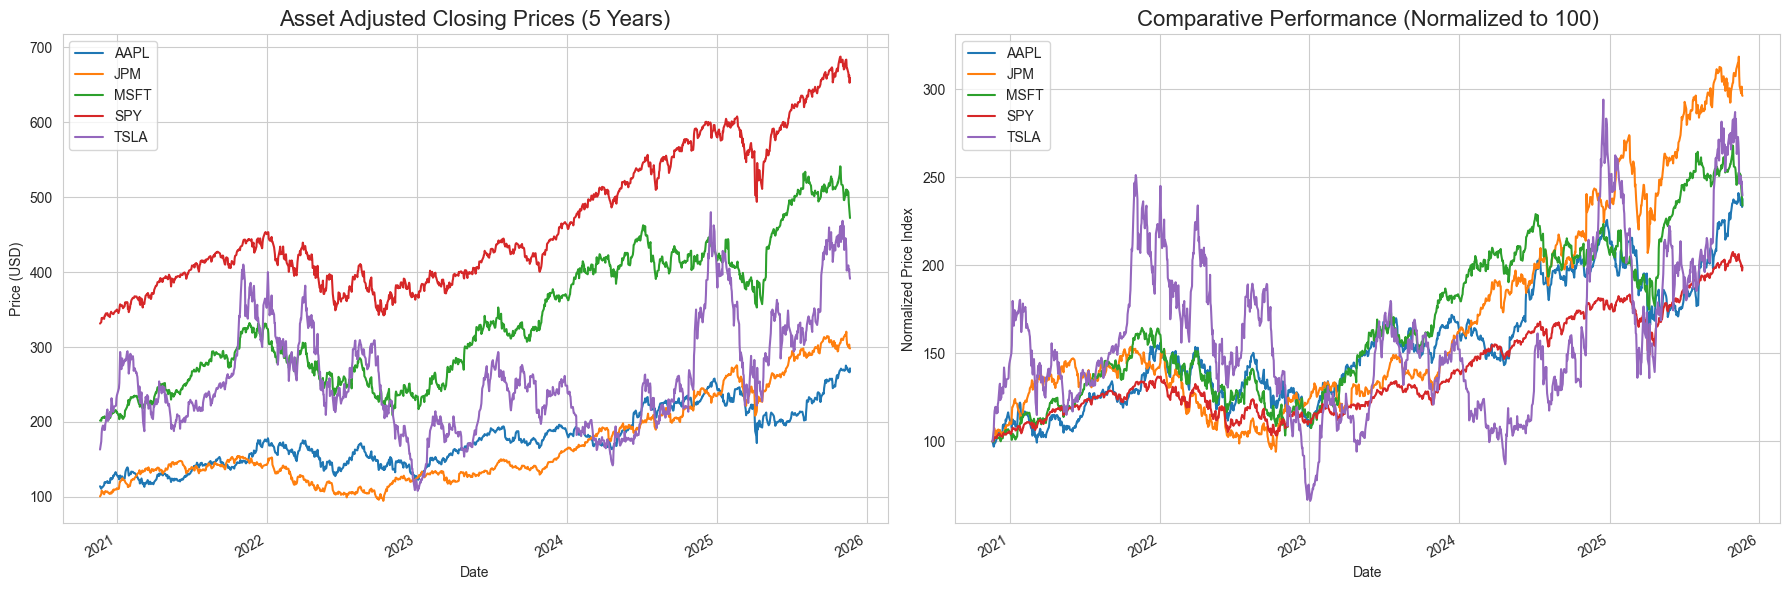

In [6]:
# Configure plotting style
sns.set_style("whitegrid")
plt.figure(figsize=(18, 6))

# --- Chart A: Price Time Series (Last 5 Years) ---
plt.subplot(1, 2, 1)
data.plot(ax=plt.gca(), legend=False)
plt.title('Asset Adjusted Closing Prices (5 Years)', fontsize=16)
plt.ylabel('Price (USD)')
plt.xlabel('Date')
plt.legend(data.columns, loc='upper left')

# --- Chart B: Comparative Performance (Normalized to 100) ---
# Normalize the price series by dividing by the starting price and multiplying by 100
normalized_prices = data.div(data.iloc[0]) * 100

plt.subplot(1, 2, 2)
normalized_prices.plot(ax=plt.gca())
plt.title('Comparative Performance (Normalized to 100)', fontsize=16)
plt.ylabel('Normalized Price Index')
plt.xlabel('Date')
plt.legend(normalized_prices.columns, loc='upper left')
plt.tight_layout()
plt.show()

### Plotting the distribution of daily log returns for each asset

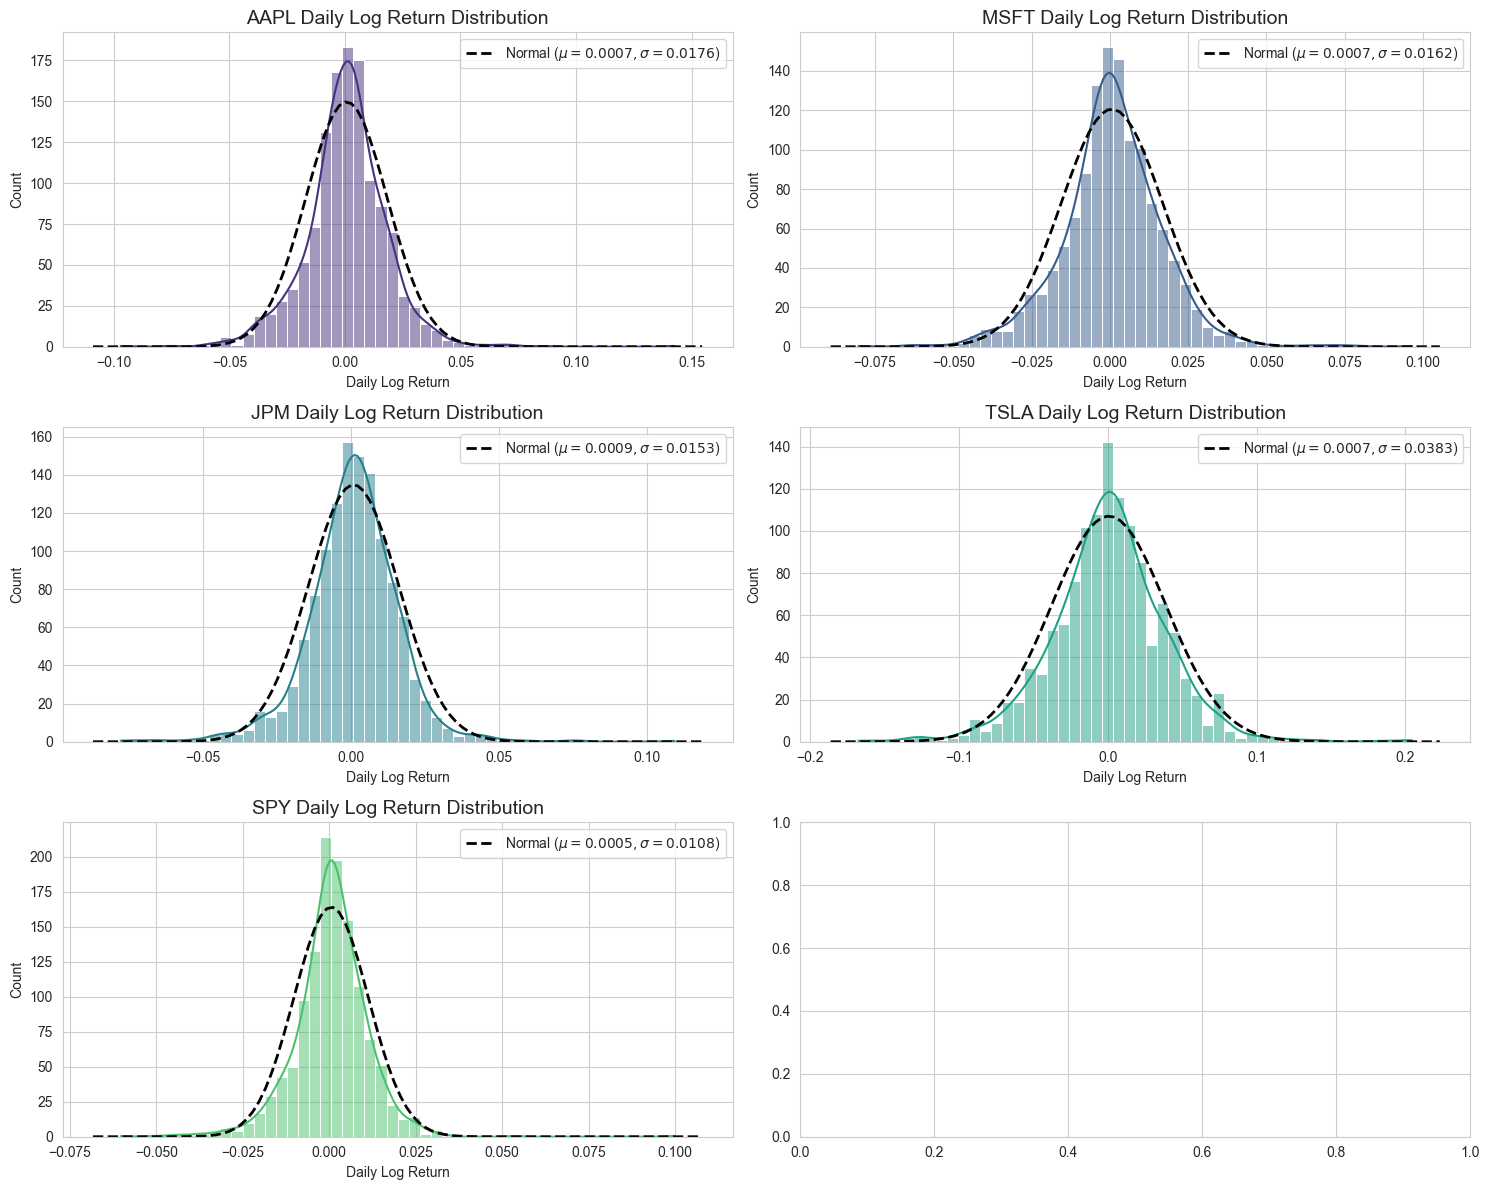

In [7]:
num_assets = len(ASSET_TICKERS)
fig, axes = plt.subplots(nrows=(num_assets + 1) // 2, ncols=2, figsize=(15, 4 * ((num_assets + 1) // 2)))

for i, ticker in enumerate(ASSET_TICKERS):
    row = i // 2
    col = i % 2
    
    # Calculate Mean and Std Dev for the Title
    mean_return = log_returns[ticker].mean()
    std_dev = log_returns[ticker].std()
    
    # Plot the histogram
    sns.histplot(log_returns[ticker].dropna(), bins=50, kde=True, ax=axes[row, col], 
                 color=sns.color_palette("viridis")[i % 6])
    
    # Add a normal distribution curve for comparison
    xmin, xmax = axes[row, col].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean_return, std_dev)
    
    # Scale the normal PDF to fit the histogram height
    scale_factor = len(log_returns[ticker]) * (xmax - xmin) / 50  # Approximation
    axes[row, col].plot(x, p * scale_factor, 'k--', linewidth=2, 
                        label=f'Normal ($\mu={mean_return:.4f}, \sigma={std_dev:.4f}$)')
    
    axes[row, col].set_title(f'{ticker} Daily Log Return Distribution', fontsize=14)
    axes[row, col].set_xlabel('Daily Log Return')
    axes[row, col].legend()

plt.tight_layout()
plt.show()